<a href="https://colab.research.google.com/github/sharkK43C7/Customer-churn-ml/blob/main/Copy_of_telco_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
y = df["Churn"]
y.head()

,Churn
0,No
1,No
2,Yes
3,No
4,Yes


In [ ]:
X = df.drop(columns=["Churn", "customerID"])
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [ ]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [ ]:
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")
X["TotalCharges"] = X["TotalCharges"].fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(include=np.number).columns

In [ ]:
import numpy as np

cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(include=np.number).columns

cat_cols, num_cols

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_y = LabelEncoder()
y_train_enc = le_y.fit_transform(y_train)
y_test_enc = le_y.transform(y_test)

In [ ]:
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train[col])
    X_test_enc[col] = le.transform(X_test[col])
    encoders[col] = le

In [ ]:
X_train_enc.shape
X_test_enc.shape

(1409, 19)

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [ ]:
log_reg.fit(X_train_enc, y_train_enc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_prob = log_reg.predict_proba(X_test_enc)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("Precision:", precision_score(y_test_enc, y_pred))
print("Recall:", recall_score(y_test_enc, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_enc, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test_enc, y_pred))

Accuracy: 0.7366926898509581
Precision: 0.5025553662691652
Recall: 0.7887700534759359
ROC-AUC: 0.8388746803069054
Confusion Matrix:
 [[743 292]
 [ 79 295]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_enc, y_train_enc)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

rf_preds = rf_model.predict(X_test_enc)
rf_proba = rf_model.predict_proba(X_test_enc)[:, 1]

print("Accuracy:", accuracy_score(y_test_enc, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test_enc, rf_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_enc, rf_preds))
print("\nClassification Report:\n", classification_report(y_test_enc, rf_preds))

Accuracy: 0.7877927608232789
ROC-AUC: 0.8241636311968792

Confusion Matrix:
 [[934 101]
 [198 176]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

log_proba = log_reg.predict_proba(X_test_enc)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    preds = (log_proba >= t).astype(int)
    print(
        f"Threshold {t:.2f} | "
        f"Precision: {precision_score(y_test_enc, preds):.2f} | "
        f"Recall: {recall_score(y_test_enc, preds):.2f}"
    )

Threshold 0.10 | Precision: 0.34 | Recall: 0.99
Threshold 0.15 | Precision: 0.37 | Recall: 0.98
Threshold 0.20 | Precision: 0.39 | Recall: 0.96
Threshold 0.25 | Precision: 0.41 | Recall: 0.94
Threshold 0.30 | Precision: 0.43 | Recall: 0.93
Threshold 0.35 | Precision: 0.44 | Recall: 0.90
Threshold 0.40 | Precision: 0.46 | Recall: 0.86
Threshold 0.45 | Precision: 0.48 | Recall: 0.83
Threshold 0.50 | Precision: 0.50 | Recall: 0.79
Threshold 0.55 | Precision: 0.52 | Recall: 0.76
Threshold 0.60 | Precision: 0.54 | Recall: 0.71
Threshold 0.65 | Precision: 0.57 | Recall: 0.67
Threshold 0.70 | Precision: 0.61 | Recall: 0.59
Threshold 0.75 | Precision: 0.65 | Recall: 0.50
Threshold 0.80 | Precision: 0.71 | Recall: 0.38
Threshold 0.85 | Precision: 0.73 | Recall: 0.19


In [ ]:
best_threshold = 0.40

In [ ]:
best_preds = (log_proba >= 0.40).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test_enc, best_preds))
print("\nClassification Report:\n", classification_report(y_test_enc, best_preds))

Confusion Matrix:
 [[658 377]
 [ 53 321]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.64      0.75      1035
           1       0.46      0.86      0.60       374

    accuracy                           0.69      1409
   macro avg       0.69      0.75      0.68      1409
weighted avg       0.80      0.69      0.71      1409



In [ ]:
import pandas as pd
import numpy as np

feature_importances = rf_model.feature_importances_

feature_names = X_train_enc.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
18,TotalCharges,0.168054
17,MonthlyCharges,0.162381
4,tenure,0.152048
14,Contract,0.112441
8,OnlineSecurity,0.057785
16,PaymentMethod,0.050653
11,TechSupport,0.048269
7,InternetService,0.033502
9,OnlineBackup,0.027449
0,gender,0.025441


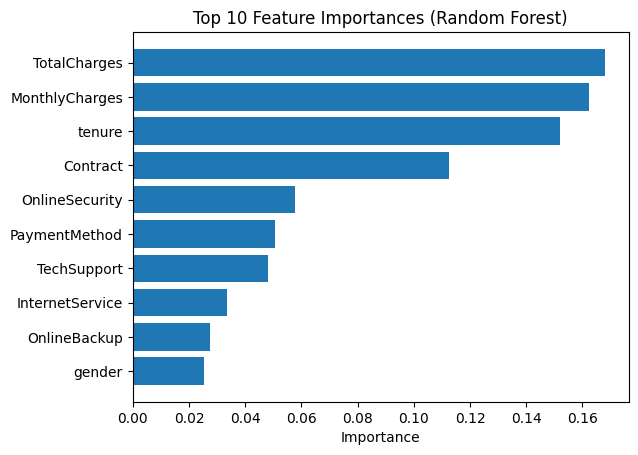

In [ ]:
import matplotlib.pyplot as plt

top_n = 10

plt.figure()
plt.barh(
    importance_df["feature"][:top_n][::-1],
    importance_df["importance"][:top_n][::-1]
)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

In [ ]:
import joblib
model_package = {
    "model": log_reg,
    "encoders": encoders,
    "label_encoder_y": le_y,
    "threshold": 0.40,
    "feature_columns": X_train.columns
}
joblib.dump(model_package, "churn_model.pkl")

['churn_model.pkl']

In [ ]:
loaded_package = joblib.load("churn_model.pkl")

model = loaded_package["model"]
encoders = loaded_package["encoders"]
le_y = loaded_package["label_encoder_y"]
threshold = loaded_package["threshold"]

In [ ]:
def predict_customer(customer_dict):
    import pandas as pd

    df = pd.DataFrame([customer_dict])

    # Encode categorical giống lúc train
    for col, le in encoders.items():
        df[col] = le.transform(df[col])

    proba = model.predict_proba(df)[:, 1][0]

    prediction = 1 if proba >= threshold else 0

    return {
        "churn_probability": round(proba, 3),
        "prediction": prediction
    }

In [ ]:
sample_customer = X.iloc[0].to_dict()

predict_customer(sample_customer)

{'churn_probability': np.float64(0.754), 'prediction': 1}